# 01 — EDA: o que a base sabe (e o que não sabe)

Painel **país × ano** (1990–2023) do World Bank + WHO GHO, consolidado na ABT
`gold/abt_country_year`. Objetivo: documentar **cobertura, confiabilidade e padrões de
ausência** antes de qualquer modelo ou teste.

In [ ]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config import settings
from src.utils.io import load_parquet
from src.analysis import eda
from src.viz import style

style.use_matplotlib()
pd.set_option("display.max_columns", 40, "display.width", 160, "display.precision", 2)
abt = load_parquet("gold", "abt_country_year")
print(f"ABT: {abt.shape[0]:,} linhas x {abt.shape[1]} colunas | "
      f"{abt.country_id.nunique()} paises | {abt.year.min()}-{abt.year.max()}")

ABT: 7,378 linhas x 37 colunas | 217 paises | 1990-2023


## 1. Cobertura por indicador
% de células país × ano preenchidas, nº de países e janela de anos.

In [ ]:
cov = eda.coverage_by_indicator(abt)
cov

,indicator,pct_filled,countries,first_year,last_year
0,fertility,100.0,217,1990,2023
1,life_expectancy,100.0,217,1990,2023
2,population,100.0,217,1990,2023
3,urban_pct,100.0,217,1990,2023
4,gdp_per_capita,95.1,214,1990,2023
5,child_mortality,90.3,196,1990,2023
6,maternal_mortality,89.4,194,1990,2023
7,dpt_imm_pct,87.2,193,1990,2023
8,measles_imm_pct,87.1,193,1990,2023
9,uhc_index,74.2,193,1990,2023


**Leitura:** demografia (LE, fertilidade, urbanização, população) é completa. Os insumos de
saúde se dividem em dois grupos: **séries de gasto, saneamento e água começam em 2000**
(nada antes), e a força de trabalho (médicos, enfermeiros, leitos) cobre só ~50% das
células — os países não reportam todo ano. `road_traffic_deaths` é um snapshot de 2021 e
não serve como série.

## 2. Missingness ao longo do tempo

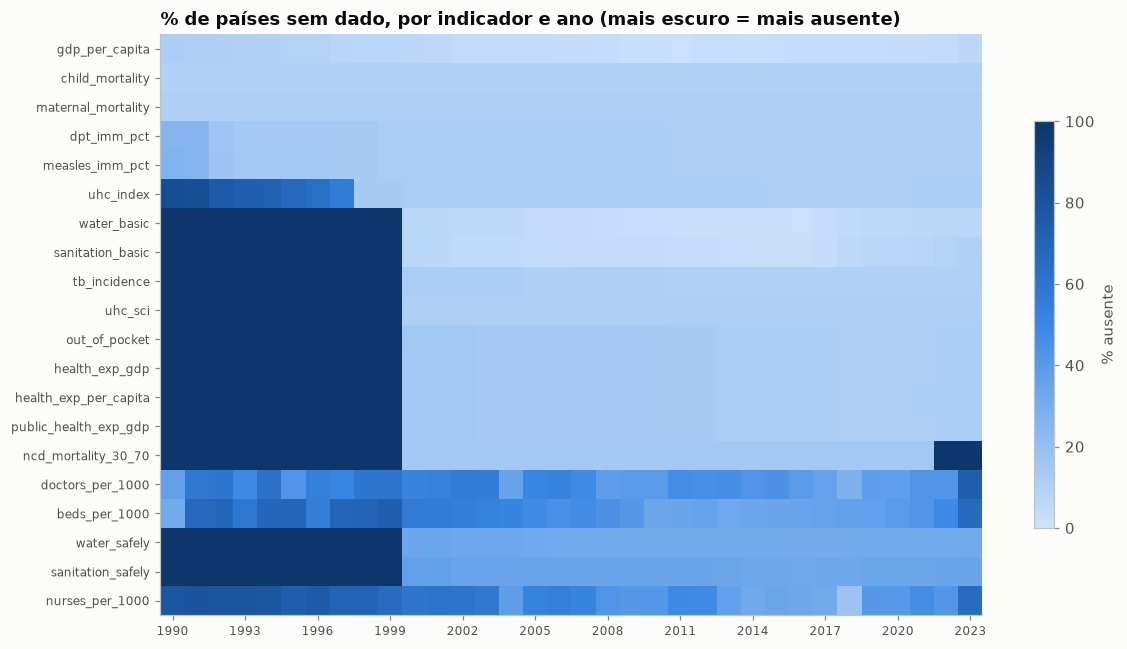

In [ ]:
cols = cov.loc[cov.pct_filled.between(3, 99.9), "indicator"].tolist()
miss = eda.missingness_by_year(abt, cols)
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(miss.values, aspect="auto", cmap=style.mpl_sequential(), vmin=0, vmax=100)
ax.set_yticks(range(len(miss.index)), miss.index, fontsize=8)
xt = list(range(0, len(miss.columns), 3))
ax.set_xticks(xt, [miss.columns[i] for i in xt], fontsize=8)
ax.grid(False)
ax.set_title("% de países sem dado, por indicador e ano (mais escuro = mais ausente)")
fig.colorbar(im, ax=ax, shrink=0.7, label="% ausente")
plt.tight_layout(); plt.show()

**Leitura:** a borda de 2000 é nítida — é por isso que o **proxy UHC** muda de composição
nessa data e o DiD usa só 2000–2023. Médicos/leitos têm "buracos" espalhados (reporte
esporádico), tratados com interpolação intra-país **só** dentro do cálculo do proxy.

## 3. O dado falta ao acaso? Missingness por grupo de renda

In [ ]:
eda.missingness_by_income(abt, cols)

income,Low income,Lower middle income,Upper middle income,High income
gdp_per_capita,10.7,0.3,1.6,8.0
child_mortality,0.0,0.0,0.0,24.4
maternal_mortality,0.0,0.0,1.7,25.6
dpt_imm_pct,4.9,1.4,3.6,27.7
measles_imm_pct,4.9,1.4,3.6,27.9
uhc_index,24.6,19.6,17.0,35.6
water_basic,31.5,31.2,32.7,32.5
sanitation_basic,31.8,31.2,32.6,33.6
tb_incidence,33.5,29.5,31.1,45.8
uhc_sci,29.4,29.4,30.6,48.3


**Leitura:** não é aleatório. Países de **baixa renda** faltam muito mais em médicos e leitos;
já o SCI oficial falta mais em **alta renda** (microestados e territórios sem estimativa WHO).
Consequência: análises "complete-case" enviesam a amostra — por isso os modelos usam XGBoost
(NaN nativo) e os testes reportam o *n* efetivo.

## 4. Distribuições

In [ ]:
eda.describe(abt, ['life_expectancy','child_mortality','gdp_per_capita','health_exp_per_capita','doctors_per_1000','uhc_index','uhc_sci'])

,count,mean,std,min,5%,50%,95%,max,skew
life_expectancy,7378.0,69.48,9.43,1.22e+01,50.91,71.39,81.81,86.37,-0.91
child_mortality,6664.0,45.31,51.60,1.30e+00,3.70,23.50,156.17,489.30,2.07
gdp_per_capita,7015.0,13590.04,22471.75,2.30e+01,314.22,4090.59,54283.96,256799.91,3.52
health_exp_per_capita,4537.0,987.54,1759.93,4.18e+00,19.22,265.72,5110.50,13473.19,2.82
doctors_per_1000,3876.0,1.98,1.54,7.00e-03,0.06,1.89,4.41,9.54,0.65
uhc_index,5473.0,0.52,0.25,0.00e+00,0.08,0.55,0.89,0.99,-0.26
uhc_sci,4632.0,62.71,18.56,1.30e+01,26.00,68.00,85.00,92.00,-0.74


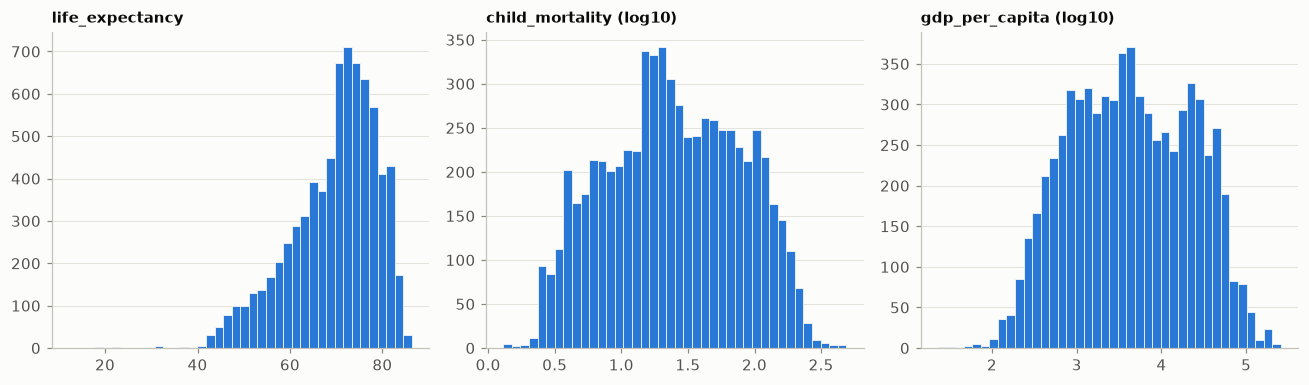

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (c, log) in zip(axes, [("life_expectancy", False), ("child_mortality", True), ("gdp_per_capita", True)]):
    s = abt[c].dropna()
    ax.hist(np.log10(s) if log else s, bins=40, color=style.HIGHLIGHT, edgecolor=style.INK["surface"], linewidth=0.5)
    ax.set_title(c + (" (log10)" if log else ""), fontsize=10)
plt.tight_layout(); plt.show()

**Leitura:** PIB, gasto e mortalidade são fortemente assimétricos (skew alto) → usar **log**
em regressões e testes não-paramétricos em comparações de grupos. A expectativa de vida tem
cauda esquerda de crises (ver §7).

## 5. Correlações (Spearman, 2019)

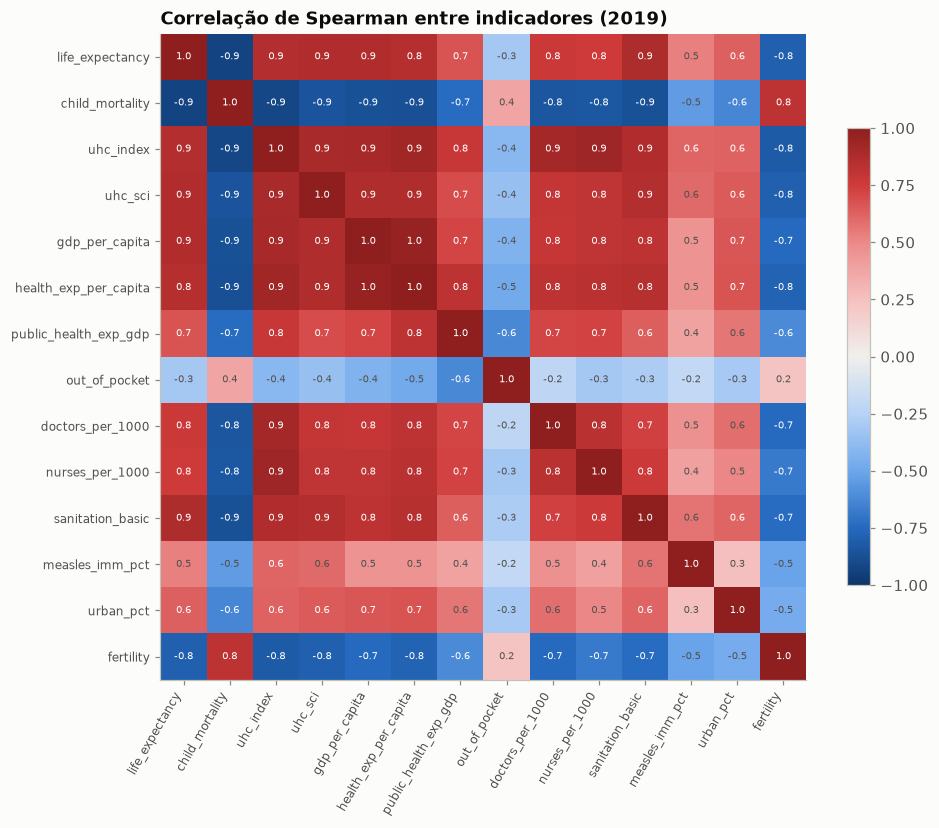

In [ ]:
cc = ['life_expectancy','child_mortality','uhc_index','uhc_sci','gdp_per_capita','health_exp_per_capita',
      'public_health_exp_gdp','out_of_pocket','doctors_per_1000','nurses_per_1000','sanitation_basic',
      'measles_imm_pct','urban_pct','fertility']
corr = eda.correlations(abt, cc, year=2019)
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap=style.mpl_diverging(), vmin=-1, vmax=1)
ax.set_xticks(range(len(cc)), cc, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(cc)), cc, fontsize=8); ax.grid(False)
for i in range(len(cc)):
    for j in range(len(cc)):
        ax.text(j, i, f"{corr.values[i,j]:.1f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(corr.values[i,j]) > 0.6 else style.INK["secondary"])
ax.set_title("Correlação de Spearman entre indicadores (2019)")
fig.colorbar(im, ax=ax, shrink=0.7); plt.tight_layout(); plt.show()

In [ ]:
print("Proxy UHC vs SCI oficial:", json.loads((settings.GOLD_DIR / "abt_quality.json").read_text())["uhc_proxy"]["vs_official_sci"])

Proxy UHC vs SCI oficial: {'n': 4607, 'pearson': 0.913, 'spearman': 0.896}


**Leitura:** quase tudo se correlaciona com quase tudo em corte transversal — o eixo comum é
**desenvolvimento** (PIB, fertilidade, urbanização). Por isso testes de hipótese precisam de
controle (log PIB) e, de preferência, variação **dentro** do país (efeitos fixos). O proxy UHC
acompanha o SCI oficial de perto (Pearson ≈ 0.91), o que valida a construção.

## 6. Tendências por renda (média ponderada por população)

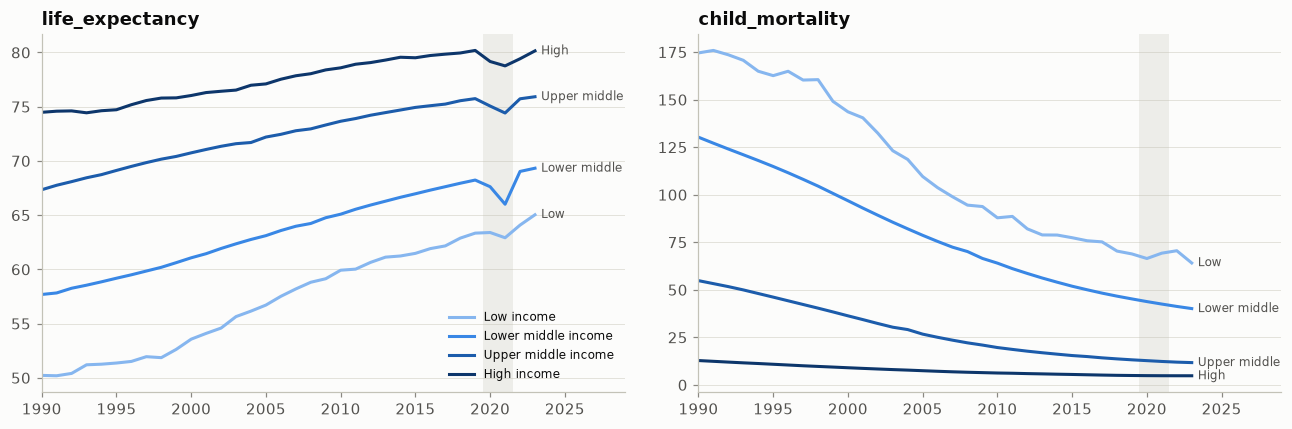

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, c in zip(axes, ["life_expectancy", "child_mortality"]):
    t = eda.trends(abt, c)
    for inc in style.INCOME_ORDER:
        s = t[t.income == inc]
        ax.plot(s.year, s[c], color=style.INCOME_COLORS[inc], label=inc)
        ax.annotate(inc.replace(" income", ""), (s.year.iloc[-1], s[c].iloc[-1]), xytext=(4, 0),
                    textcoords="offset points", fontsize=8, color=style.INK["secondary"], va="center")
    ax.axvspan(2019.5, 2021.5, color=style.CONTEXT, alpha=0.25, lw=0)
    ax.set_title(c); ax.set_xlim(1990, 2029)
axes[0].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**Leitura:** convergência — os países de baixa renda ganharam **~15 anos** de expectativa de
vida desde 1990 (50 → 65), contra ~6 anos dos de alta renda. A mortalidade <5 caiu em
todos os grupos. A faixa cinza marca **2020–2021 (COVID)**: a única queda simultânea em
todos os grupos de renda no período.

## 7. Choques e outliers: quedas abruptas de expectativa de vida

In [ ]:
eda.yoy_shocks(abt).head(12)

,country_name,region,year,life_expectancy,delta
0,Central African Republic,Sub-Saharan Africa,2009,14.66,-35.21
1,Rwanda,Sub-Saharan Africa,1994,12.16,-30.78
2,"Somalia, Fed. Rep.",Sub-Saharan Africa,1991,25.42,-21.48
3,Central African Republic,Sub-Saharan Africa,2022,18.82,-21.46
4,Central African Republic,Sub-Saharan Africa,2019,31.53,-20.77
5,Bosnia and Herzegovina,Europe & Central Asia,1992,51.97,-19.85
6,"Somalia, Fed. Rep.",Sub-Saharan Africa,2011,32.45,-16.45
7,Haiti,Latin America & Caribbean,2010,45.58,-16.12
8,South Sudan,Sub-Saharan Africa,1998,19.05,-14.02
9,South Sudan,Sub-Saharan Africa,1995,31.51,-13.35


In [ ]:
eda.covid_impact(abt)

year,drop_2019_2021,recovery_2021_2023
region,,
"Middle East, North Africa, Afghanistan & Pakistan",-1.86,2.16
Latin America & Caribbean,-1.82,2.62
Europe & Central Asia,-1.28,1.54
South Asia,-1.22,2.48
North America,-0.71,0.56
Sub-Saharan Africa,-0.39,1.69
East Asia & Pacific,-0.18,0.78


**Leitura:** as maiores quedas são **crises reais**, não erro de dado (genocídio de Ruanda 1994,
conflitos na República Centro-Africana, Somália, Bósnia, terremoto no Haiti 2010). Ficam na base,
sinalizadas como aviso em `quality_checks.json`. O COVID tirou ~1.8 ano (mediana) de América
Latina e Oriente Médio/Norte da África entre 2019 e 2021, e a recuperação até 2023 foi completa
na maioria das regiões. Isso importa para os modelos: o **período de teste (2020–2023) é um choque**
fora da distribuição de treino.

## 8. Comparativo regional (medianas, 2019)

In [ ]:
eda.regional_comparison(abt, 2019, ['life_expectancy','child_mortality','uhc_index','doctors_per_1000','health_exp_per_capita','sanitation_basic'])

,life_expectancy,child_mortality,uhc_index,doctors_per_1000,health_exp_per_capita,sanitation_basic
region,,,,,,
North America,81.25,5.85,0.84,2.95,7824.55,99.68
Europe & Central Asia,79.35,4.05,0.80,3.57,1465.12,98.67
"Middle East, North Africa, Afghanistan & Pakistan",75.81,14.90,0.58,1.80,294.93,96.94
Latin America & Caribbean,75.33,15.00,0.60,2.36,506.03,91.24
South Asia,72.32,26.85,0.46,0.85,88.20,74.06
East Asia & Pacific,72.29,20.00,0.63,0.76,266.69,90.45
Sub-Saharan Africa,62.93,55.70,0.27,0.12,52.59,37.11


## Conclusões da EDA

- **Confiável:** demografia e alvos (LE, mortalidade <5) — cobertura quase completa, 217 países.
- **Parcial:** insumos de saúde (só a partir de 2000 p/ gasto/saneamento; força de trabalho esporádica).
- **Missing não aleatório:** depende da renda → usar modelos que lidam com NaN e reportar *n*.
- **Confundimento por desenvolvimento** domina as correlações → testes com controles e efeitos fixos (notebook 03).
- **Choques** (guerras, COVID) são reais e afetam o período de teste dos modelos (notebook 04).